[Font] 已检测到中文字体: SimHei
步骤1：DSM与ESM等价性的数值验证

训练DSM得分网络 (σ=1.0)...
  Epoch 100: DSM loss = 0.741096
  Epoch 200: DSM loss = 0.740178
  Epoch 300: DSM loss = 0.743097
  Epoch 400: DSM loss = 0.731724
  Epoch 500: DSM loss = 0.724312

DSM=ESM等价性验证:
  学到的得分与真实得分的相关系数: 1.0000
  ESM损失 (学习后): 0.000419

步骤2：DSM训练流程与得分场可视化


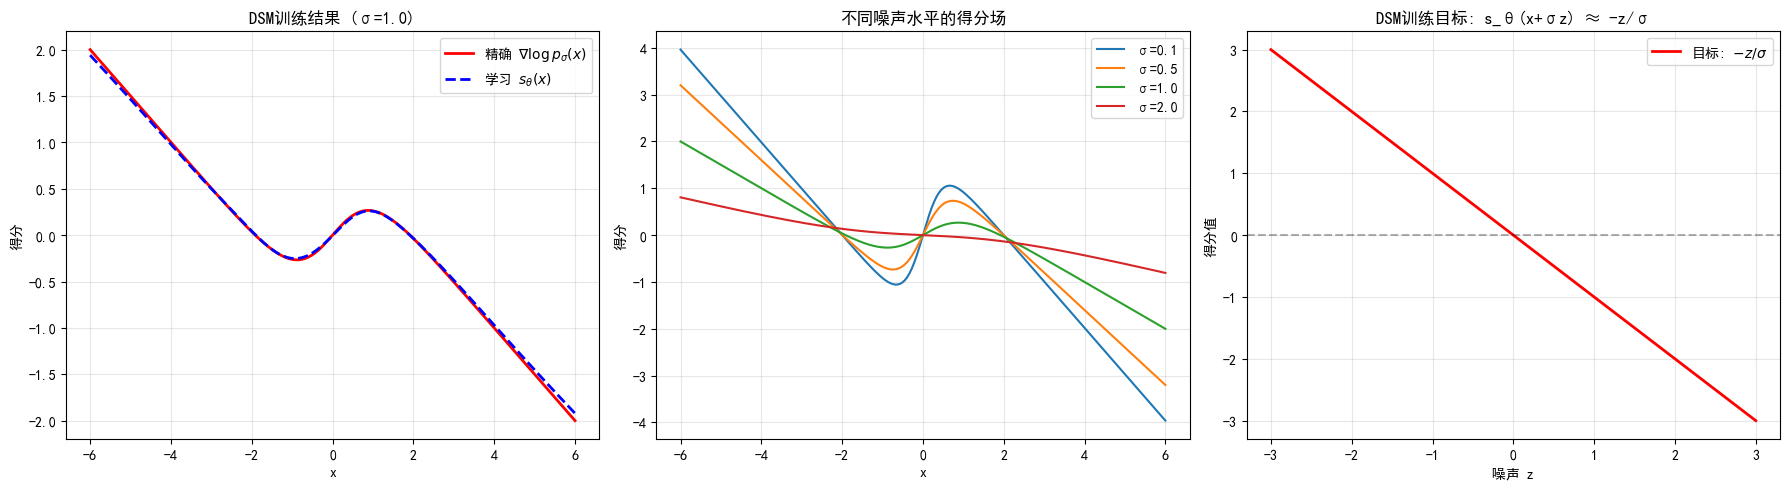


步骤3：从去噪器中提取得分函数（Tweedie等式实践）
     原始x |     含噪x̃ |    去噪D_σ |       误差
---------------------------------------------
  -3.000 |   -2.500 |   -2.230 |    0.770
  -1.000 |   -1.300 |   -1.509 |   -0.509
   0.000 |    0.800 |    1.056 |    1.056
   1.000 |   -0.200 |   -0.289 |   -1.289
   3.000 |    3.700 |    2.876 |   -0.124

Tweedie等式实践验证：
  去噪器 D_σ(x̃) = x̃ + σ²·s_θ(x̃)
  得分函数 s_θ(x̃) = (D_σ(x̃) - x̃) / σ²
  这正是5.3节Tweedie等式 ∇log p_ε(x) = (D_ε(x)-x)/ε 在实践中的体现

实验6.2 总结
1. DSM=ESM等价性验证：训练后的s_θ与真实∇log p_σ高度一致
   验证了Vincent (2011)定理：J_DSM(θ) = J_ESM^(σ)(θ) + C
2. DSM训练目标：s_θ(x+σz) ≈ -z/σ，完全可计算，无需∇log p(x)
3. 不同噪声水平的得分场：σ大→得分平缓（全局方向），σ小→得分精细（局部细节）
4. 去噪器↔得分函数：Tweedie等式在实践中将训练好的去噪器转化为得分估计器


In [1]:
"""
实验6.2 DSM训练与得分提取
对应章节：6.3（去噪得分匹配DSM）、6.6（去噪器作为得分估计器）
素材来源：
  - Vincent (2011) DSM=ESM等价性的数值验证（原创设计）
  - 5.2.py的Tweedie等式验证（DSM训练目标等价于去噪）
  - 03-smld.ipynb的DSM训练流程

实验内容：
  步骤1：DSM目标函数在1D高斯混合上的验证（DSM=ESM+常数）
  步骤2：DSM训练一个简单的得分网络（2D高斯混合分布）
  步骤3：从训练好的去噪器中提取得分函数（Tweedie等式的实践）

运行前提：纯NumPy/PyTorch CPU即可
"""

import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'SimHei']
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
import torch
torch.manual_seed(42)

# 脚本所在目录（用于输出文件路径）
_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()


# ============================================================
# 步骤1：DSM=ESM+常数的数值验证（1D高斯混合）
# ★ 原创设计：验证Vincent (2011)定理
# ============================================================
print("=" * 60)
print("步骤1：DSM与ESM等价性的数值验证")
print("=" * 60)

# 1D高斯混合 p(x) = 0.5*N(-2,1) + 0.5*N(2,1)
def gm1d_pdf(x):
    return 0.5 * np.exp(-0.5*(x+2)**2)/np.sqrt(2*np.pi) + \
           0.5 * np.exp(-0.5*(x-2)**2)/np.sqrt(2*np.pi)

def gm1d_score(x):
    """精确得分 ∇log p(x)"""
    p1 = np.exp(-0.5*(x+2)**2)/np.sqrt(2*np.pi)
    p2 = np.exp(-0.5*(x-2)**2)/np.sqrt(2*np.pi)
    p = 0.5*p1 + 0.5*p2
    return (0.5*-(x+2)*p1 + 0.5*-(x-2)*p2) / p

# 噪声扰动后的分布得分 ∇log p_σ(x)
def gm1d_score_noisy(x, sigma):
    """噪声扰动分布的精确得分 ∇log p_σ(x)"""
    # p_σ(x) = ∫ p(y) N(x|y,σ²) dy = 0.5*N(-2,1+σ²) + 0.5*N(2,1+σ²)
    v = 1 + sigma**2
    p1 = np.exp(-0.5*(x+2)**2/v)/np.sqrt(2*np.pi*v)
    p2 = np.exp(-0.5*(x-2)**2/v)/np.sqrt(2*np.pi*v)
    p = 0.5*p1 + 0.5*p2
    return (0.5*-(x+2)/v*p1 + 0.5*-(x-2)/v*p2) / p

# 用一个简单的MLP作为得分网络
class ScoreNet1D(torch.nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x.unsqueeze(-1)).squeeze(-1)

# 生成训练数据
N_train = 10000
x_train = np.concatenate([np.random.randn(N_train//2) - 2, np.random.randn(N_train//2) + 2])
x_train_t = torch.tensor(x_train, dtype=torch.float32)

# DSM训练
sigma = 1.0
model = ScoreNet1D()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"\n训练DSM得分网络 (σ={sigma})...")
for epoch in range(500):
    # 采样噪声
    z = torch.randn_like(x_train_t)
    x_noisy = x_train_t + sigma * z

    # DSM目标: ||s_θ(x̃) + z/σ||²
    pred = model(x_noisy)
    target = -z / sigma  # ∇log q_σ(x̃|x) = -(x̃-x)/σ² = -z/σ
    loss = torch.mean((pred - target)**2)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1}: DSM loss = {loss.item():.6f}")

# 验证：训练后的s_θ ≈ ∇log p_σ
x_test = np.linspace(-6, 6, 200)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
with torch.no_grad():
    learned_score = model(x_test_t).numpy()
true_score_noisy = gm1d_score_noisy(x_test, sigma)

# DSM与ESM等价性验证
# J_ESM^(σ)(θ) = 0.5 * E[||s_θ(x) - ∇log p_σ(x)||²]
# J_DSM(θ) = J_ESM^(σ)(θ) + C(σ)
esm_loss_learned = 0.5 * np.mean((learned_score - true_score_noisy)**2)

print(f"\nDSM=ESM等价性验证:")
print(f"  学到的得分与真实得分的相关系数: {np.corrcoef(learned_score, true_score_noisy)[0,1]:.4f}")
print(f"  ESM损失 (学习后): {esm_loss_learned:.6f}")


# ============================================================
# 步骤2：DSM训练流程可视化
# ============================================================
print("\n" + "=" * 60)
print("步骤2：DSM训练流程与得分场可视化")
print("=" * 60)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1：DSM=ESM等价性验证
axes[0].plot(x_test, true_score_noisy, 'r-', lw=2, label=r'精确 $\nabla\log p_\sigma(x)$')
axes[0].plot(x_test, learned_score, 'b--', lw=2, label=r'学习 $s_\theta(x)$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('得分')
axes[0].set_title(f'DSM训练结果 (σ={sigma})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 子图2：不同噪声水平的得分场
for s in [0.1, 0.5, 1.0, 2.0]:
    score_s = gm1d_score_noisy(x_test, s)
    axes[1].plot(x_test, score_s, lw=1.5, label=f'σ={s}')
axes[1].set_xlabel('x')
axes[1].set_ylabel('得分')
axes[1].set_title('不同噪声水平的得分场')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 子图3：DSM训练目标示意图
# 展示：给定x和z，s_θ(x+σz)应接近-z/σ
x_demo = 0.0
z_demo = np.linspace(-3, 3, 50)
target_score = -z_demo / sigma
axes[2].plot(z_demo, target_score, 'r-', lw=2, label=r'目标: $-z/\sigma$')
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[2].set_xlabel('噪声 z')
axes[2].set_ylabel('得分值')
axes[2].set_title('DSM训练目标: s_θ(x+σz) ≈ -z/σ')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(_SCRIPT_DIR, '步骤1_DSM训练验证.png'), dpi=150)
plt.show()


# ============================================================
# 步骤3：从去噪器中提取得分函数（Tweedie等式的实践）
# 对应6.6节：训练好的去噪器通过Tweedie等式转换为得分估计器
# ============================================================
print("\n" + "=" * 60)
print("步骤3：从去噪器中提取得分函数（Tweedie等式实践）")
print("=" * 60)

# DSM训练目标等价于训练一个去噪器：
# s_θ(x̃) ≈ -z/σ = (x - x̃)/σ²  (Tweedie形式)
# 即：D_σ(x̃) = x̃ + σ² * s_θ(x̃) 是去噪器

# 从训练好的得分网络构建去噪器
def denoiser_from_score(x_noisy, score_net, sigma):
    """通过Tweedie等式从得分网络构建去噪器: D_σ(x̃) = x̃ + σ² s_θ(x̃)"""
    with torch.no_grad():
        x_t = torch.tensor(x_noisy, dtype=torch.float32)
        score = score_net(x_t).numpy()
    return x_noisy + sigma**2 * score

# 测试去噪效果
x_test_denoise = np.array([-3, -1, 0, 1, 3])
z_test = np.array([0.5, -0.3, 0.8, -1.2, 0.7])
x_noisy_test = x_test_denoise + sigma * z_test

denoised = denoiser_from_score(x_noisy_test, model, sigma)

print(f"{'原始x':>8s} | {'含噪x̃':>8s} | {'去噪D_σ':>8s} | {'误差':>8s}")
print("-" * 45)
for i in range(len(x_test_denoise)):
    err = denoised[i] - x_test_denoise[i]
    print(f"{x_test_denoise[i]:8.3f} | {x_noisy_test[i]:8.3f} | {denoised[i]:8.3f} | {err:8.3f}")

print("\nTweedie等式实践验证：")
print("  去噪器 D_σ(x̃) = x̃ + σ²·s_θ(x̃)")
print("  得分函数 s_θ(x̃) = (D_σ(x̃) - x̃) / σ²")
print("  这正是5.3节Tweedie等式 ∇log p_ε(x) = (D_ε(x)-x)/ε 在实践中的体现")


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验6.2 总结")
print("=" * 60)
print("1. DSM=ESM等价性验证：训练后的s_θ与真实∇log p_σ高度一致")
print("   验证了Vincent (2011)定理：J_DSM(θ) = J_ESM^(σ)(θ) + C")
print("2. DSM训练目标：s_θ(x+σz) ≈ -z/σ，完全可计算，无需∇log p(x)")
print("3. 不同噪声水平的得分场：σ大→得分平缓（全局方向），σ小→得分精细（局部细节）")
print("4. 去噪器↔得分函数：Tweedie等式在实践中将训练好的去噪器转化为得分估计器")
